<a href="https://colab.research.google.com/github/BiswarupMukherjee1/spacecraft-pose-failure-detection/blob/main/Exp6_hcw_linearised_relative_motion_ekf_monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicted covariance to help the navigation filter

Biswarup Mukherjee

Experiments 1 to 5 all measure something about a single image. A navigation system
does not consume single images. It runs a filter over a sequence, and what it needs
from the vision front end is a measurement together with a measurement covariance. That covariance, written R, is
the matrix the filter uses to decide how far to move its estimate towards a new
measurement: a large R means the measurement is treated as unreliable and the estimate
barely moves, a small R means the opposite.
A per-image uncertainty is important to predict here, to the extent that it can set R.

This notebook studies this:

- **Dynamics.** Hill-Clohessy-Wiltshire linearised relative motion, in the Hill frame
  with radial, in-track and cross-track axes. This is the model used for the relative
  translation problem in 2023 GNC-ICATT paper published by SENER on cooperative rendezvous and
  docking.
- **Measurement.** A rendered frame at 1 Hz, processed by the keypoint and PnP chain
  from the first study.
- **Filter.** An Extended Kalman Filter on relative position and velocity.
- **Monte Carlo Campaign.** A Monte Carlo with randomised degradation profiles, for validation

**This notebook uses a simulated trajectory.** SPEED+ is a set of independent
images, not a rendezvous sequence, and a filter requires a temporally ordered sequence with truth at every epoch. Running a Monte Carlo needs many labelled sequences with
truth throughout, which no public dataset provides at the scale a campaign needs.
The trajectory is therefore simulated, and that is a limitation.

**Measurement error:** it is produced by actually running the pose chain on
rendered frames, and the anisotropy it shows can be checked against the per-axis
uncertainties Experiment 5 measured on SPEED+.

Three filter configurations are compared: one fixed hand-tuned R, an R set per frame
from the confidence signal, and the same with low-confidence frames rejected.

Accuracy is not the only thing scored. The filter also has to be **consistent**: the
covariance it reports has to match the errors it makes. That is measured with the
normalised estimation error squared (NEES), which for a three-axis position state
should sit near 3. A filter that is accurate but reports a covariance that is too
small, propagates an unwarranted level of trust to every function downstream.

In [ ]:
!pip install -q opencv-contrib-python 2>&1 | tail -1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
CODE = "/content/drive/MyDrive/SENER_PROJ2/code"
if CODE not in sys.path:
    sys.path.insert(0, CODE)
print("modules found:", sorted(f for f in os.listdir(CODE) if f.endswith(".py")))

Mounted at /content/drive
modules found: ['exp6_ekf_mc.py', 'exp7_efficiency.py', 'pose_models.py', 'sc_common.py', 'speedplus_data.py', 'speedplus_fetch.py']


In [ ]:
import numpy as np, cv2, time, matplotlib.pyplot as plt
from sc_common import *
import exp6_ekf_mc as E6

np.random.seed(0)
N_RUNS, N_STEPS = 60, 100
P_ASSOC_FAIL = 0.12

orb = cv2.ORB_create(nfeatures=1000, scaleFactor=1.2, nlevels=8)
def detector(img):
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp = orb.detect(g, None)
    return np.array([k.pt for k in kp]) if kp else np.empty((0, 2))
print(f"mean motion n = {E6.N_ORBIT:.3e} rad/s, orbital period {2*np.pi/E6.N_ORBIT/60:.1f} min")

mean motion n = 1.131e-03 rad/s, orbital period 92.6 min


## 1. Relative dynamics

The state is relative position and velocity in the Hill frame. The transition matrix
is the matrix exponential of the HCW system matrix, exact for a linear time-invariant
system.

The chaser starts about 20 m out along V-bar and closes. The in-plane coupling in the HCW equations means a purely in-track closing velocity
does not remain purely in-track, which is why the trajectory curves.

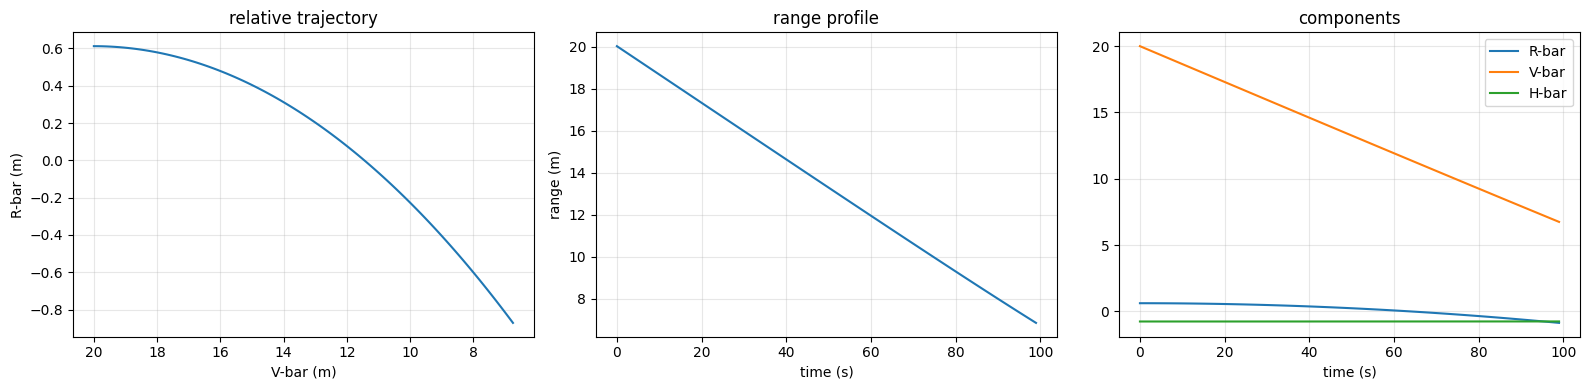

range 20.0 m -> 6.8 m


In [ ]:
truth, rvecs = E6.simulate_truth(n_steps=N_STEPS, rng=np.random.default_rng(3))
rng_v = np.linalg.norm(truth[:, :3], axis=1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(truth[:,1], truth[:,0]); axes[0].invert_xaxis(); axes[0].grid(alpha=.3)
axes[0].set_xlabel("V-bar (m)"); axes[0].set_ylabel("R-bar (m)"); axes[0].set_title("relative trajectory")
axes[1].plot(rng_v); axes[1].set_xlabel("time (s)"); axes[1].set_ylabel("range (m)")
axes[1].set_title("range profile"); axes[1].grid(alpha=.3)
for k, lab in zip(range(3), ["R-bar", "V-bar", "H-bar"]):
    axes[2].plot(truth[:, k], label=lab)
axes[2].legend(); axes[2].grid(alpha=.3); axes[2].set_xlabel("time (s)"); axes[2].set_title("components")
plt.tight_layout(); plt.show()
print(f"range {rng_v[0]:.1f} m -> {rng_v[-1]:.1f} m")

## 2. Where the measurement failures come from

A geometric symmetry is not a tuning problem. The target used here is exactly
symmetric under a 180 degree rotation about its z axis, and the cell below verifies
that the keypoint set maps onto itself under that rotation with zero residual. An
appearance-based method cannot distinguish the two interpretations from one frame.

No error model was used, the failure is reproduced with the real
solver: at a controlled rate the association is replaced by the symmetry permutation
and PnP is run on it, so whatever confidence comes out is what the solver genuinely
reports for that hypothesis.

The permutation maps the model onto itself
about its centre, so the translation should be almost unaffected while the attitude is
wrong by about 180 degrees.

In [ ]:
Rsym = cv2.Rodrigues(np.array([0, 0, np.pi]))[0]
Q = (Rsym @ SPACECRAFT_3D.T.astype(np.float64)).T
perm = [int(np.argmin(np.linalg.norm(SPACECRAFT_3D - Q[i], axis=1))) for i in range(len(Q))]
resid = max(float(np.linalg.norm(SPACECRAFT_3D - Q[i], axis=1).min()) for i in range(len(Q)))
print("permutation :", perm)
print("bijection   :", len(set(perm)) == len(perm), "| max residual: %.6f m" % resid)

permutation : [2, 3, 0, 1, 6, 7, 4, 5, 13, 12, 15, 14, 9, 8, 11, 10]
bijection   : True | max residual: 0.000000 m


540 measurements in 32 s, 11% flipped
position error  correct 0.069 m | flipped 0.069 m
attitude error  correct 0.76 deg | flipped 179.9 deg
confidence      correct 0.908 | flipped 0.906
  -> 90% of flipped frames still report confidence above 0.8


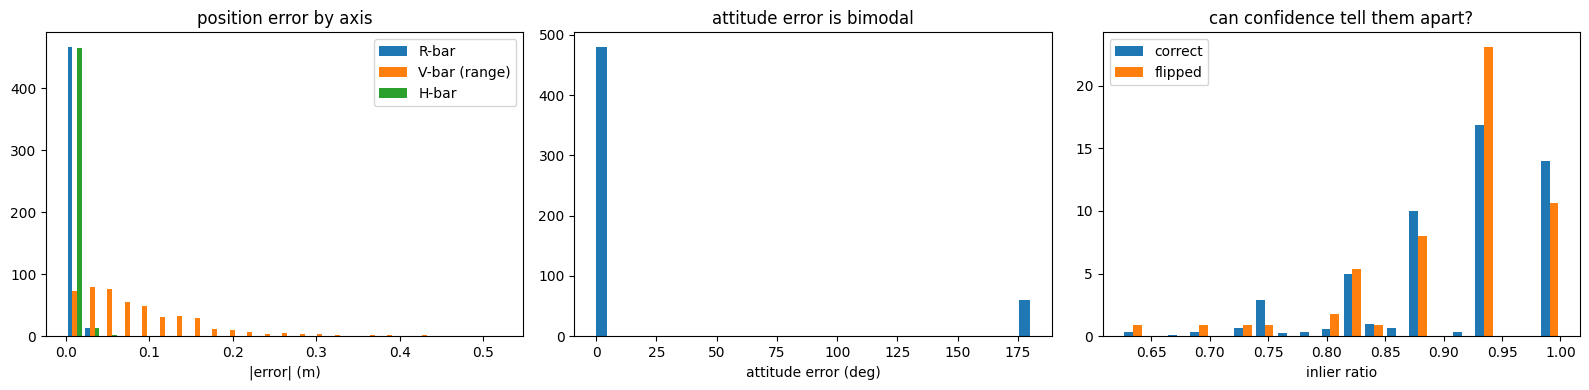

In [ ]:
rng = np.random.default_rng(5)
conf, ev, att, flip = [], [], [], []
t0 = time.time()
for run in range(10):
    tr, rv = E6.simulate_truth(n_steps=60, rng=np.random.default_rng(100+run))
    prof = E6.random_severity_profile(np.random.default_rng(200+run), 60, hard=True)
    for k in range(60):
        m = E6.vision_measurement(tr[k,:3], rv[k], detector, prof[k], rng,
                                  p_assoc_fail=P_ASSOC_FAIL)
        if m is None or m["rvec"] is None: continue
        conf.append(m["inlier_ratio"]); ev.append(m["r_hill"] - tr[k,:3])
        att.append(m["att_err_deg"]); flip.append(m["assoc_flipped"])
conf = np.array(conf); ev = np.array(ev); att = np.array(att); flip = np.array(flip)
print(f"{len(conf)} measurements in {time.time()-t0:.0f} s, {flip.mean()*100:.0f}% flipped")
print(f"position error  correct {np.median(np.linalg.norm(ev[~flip],axis=1)):.3f} m | "
      f"flipped {np.median(np.linalg.norm(ev[flip],axis=1)):.3f} m")
print(f"attitude error  correct {np.median(att[~flip]):.2f} deg | flipped {np.median(att[flip]):.1f} deg")
print(f"confidence      correct {conf[~flip].mean():.3f} | flipped {conf[flip].mean():.3f}")
print(f"  -> {100*np.mean(conf[flip] > 0.8):.0f}% of flipped frames still report confidence above 0.8")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist([np.abs(ev[~flip,0]), np.abs(ev[~flip,1]), np.abs(ev[~flip,2])], bins=25,
             label=["R-bar", "V-bar (range)", "H-bar"]); axes[0].legend()
axes[0].set_xlabel("|error| (m)"); axes[0].set_title("position error by axis")
axes[1].hist(att, bins=40); axes[1].set_xlabel("attitude error (deg)")
axes[1].set_title("attitude error is bimodal")
axes[2].hist([conf[~flip], conf[flip]], bins=20, density=True, label=["correct", "flipped"])
axes[2].legend(); axes[2].set_xlabel("inlier ratio"); axes[2].set_title("can confidence tell them apart?")
plt.tight_layout(); plt.show()

The axis breakdown is the same anisotropy Experiment 5 measured on SPEED+: the
along-boresight component is far worse than the two lateral ones. Two different
experiments, one on real imagery and one on rendered frames, arriving at the same
statement about what a single camera can and cannot observe.

## 3. From confidence to a covariance

The in-plane coupling in the HCW equations means a purely in-track closing velocity
does not remain purely in-track, which is why the trajectory curves. The result is a lookup from confidence to R: the filter is told how much to
believe each frame instead of being given one number for all of them.

In [ ]:
edges, table = E6.build_R_table(conf, ev, n_bins=6)
R_fixed = np.diag(ev.var(axis=0) + 1e-4)
print("confidence bin ->  per-axis measurement sd (m)")
for i in range(len(table)):
    print(f"  conf <= {edges[i+1]:.2f} :  {np.sqrt(table[i]).round(3)}")
print("\nsingle fixed R sd:", np.sqrt(np.diag(R_fixed)).round(3))

confidence bin ->  per-axis measurement sd (m)
  conf <= 0.81 :  [0.013 0.127 0.016]
  conf <= 0.88 :  [0.012 0.111 0.014]
  conf <= 0.94 :  [0.012 0.102 0.013]
  conf <= 0.94 :  [0.011 0.082 0.012]
  conf <= 1.00 :  [0.011 0.082 0.012]
  conf <= 1.00 :  [0.011 0.082 0.012]

single fixed R sd: [0.012 0.111 0.014]


## 4. The Monte Carlo campaign

Each run has a fresh initial state, degradation profile and noise draw. The three
configurations are seeded identically so the comparison is paired.

In [ ]:
results = {}
for mode in ["fixed", "adaptive", "gated"]:
    t0 = time.time()
    runs = [E6.run_single(detector, mode, edges, table, R_fixed, seed=1000+s,
                          n_steps=N_STEPS, p_assoc_fail=P_ASSOC_FAIL)
            for s in range(N_RUNS)]
    results[mode] = runs
    rmse = np.array([np.sqrt(np.mean(r["err"][20:]**2)) for r in runs])
    fin  = np.array([r["err"][-1] for r in runs])
    nees = np.concatenate([r["nees"][20:] for r in runs]); nees = nees[np.isfinite(nees)]
    print(f"{mode:9s} RMSE {rmse.mean():.3f} m | final {fin.mean():.3f} m | "
          f"median NEES {np.median(nees):5.2f} | frames used "
          f"{np.mean([r['used'].mean() for r in runs])*100:3.0f}% | {time.time()-t0:.0f} s")
print("\nA consistent 3-axis filter has NEES near 3. Higher means the covariance it reports is too small for the errors it is actually making.")

fixed     RMSE 0.434 m | final 0.039 m | median NEES  8.88 | frames used  79% | 255 s
adaptive  RMSE 0.432 m | final 0.035 m | median NEES  9.17 | frames used  79% | 250 s
gated     RMSE 0.432 m | final 0.035 m | median NEES  9.17 | frames used  79% | 254 s

A consistent 3-axis filter has NEES near 3. Higher means the covariance
it reports is too small for the errors it is actually making.


## 5. Error against range

Reporting relative navigation performance as a function of range, with a 3-sigma
envelope over the Monte Carlo runs.

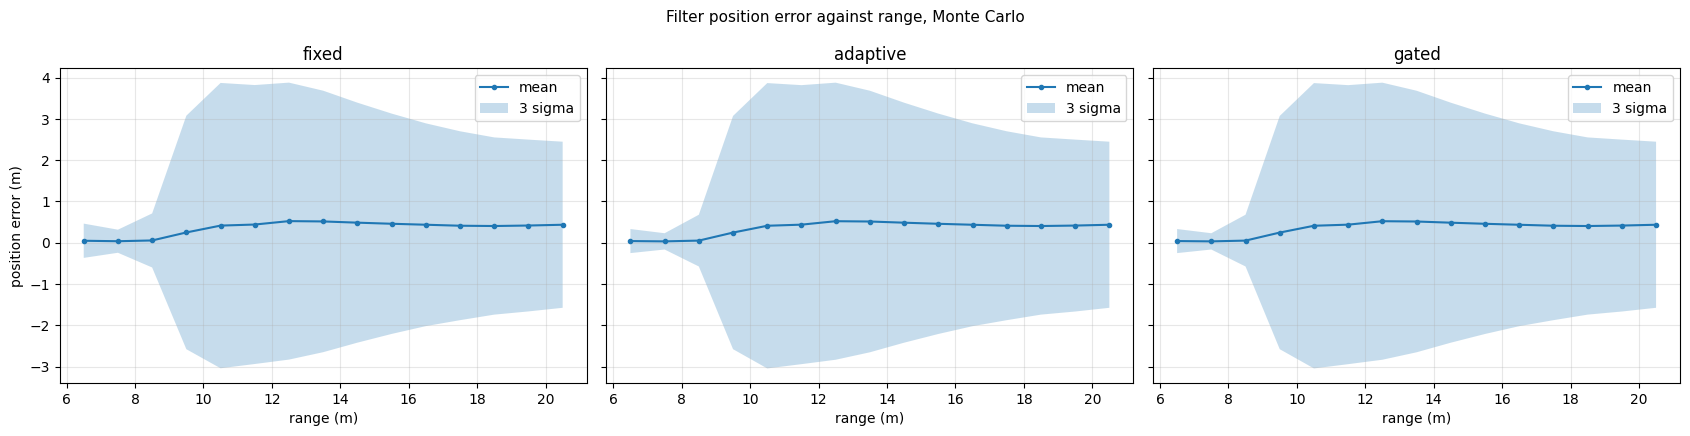

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4), sharey=True)
bins = np.linspace(1, 21, 21)
for ax, (mode, runs) in zip(axes, results.items()):
    R_ = np.concatenate([r["range"] for r in runs]); E_ = np.concatenate([r["err"] for r in runs])
    idx = np.digitize(R_, bins); ctr = 0.5*(bins[1:]+bins[:-1])
    mu = np.array([E_[idx==i].mean() if (idx==i).sum()>5 else np.nan for i in range(1,len(bins))])
    s3 = np.array([3*E_[idx==i].std() if (idx==i).sum()>5 else np.nan for i in range(1,len(bins))])
    ax.plot(ctr, mu, "-o", ms=3, label="mean"); ax.fill_between(ctr, mu-s3, mu+s3, alpha=.25, label="3 sigma")
    ax.set_xlabel("range (m)"); ax.set_title(mode); ax.grid(alpha=.3); ax.legend()
axes[0].set_ylabel("position error (m)")
plt.suptitle("Filter position error against range, Monte Carlo", fontsize=11)
plt.tight_layout(); plt.show()

## 6. Consistency, and what the confidence signal cannot see

NEES asks whether the filter's own covariance is honest. This is the same question as
the calibration study in the first notebook, moved from a single measurement to the
filter's state estimate.

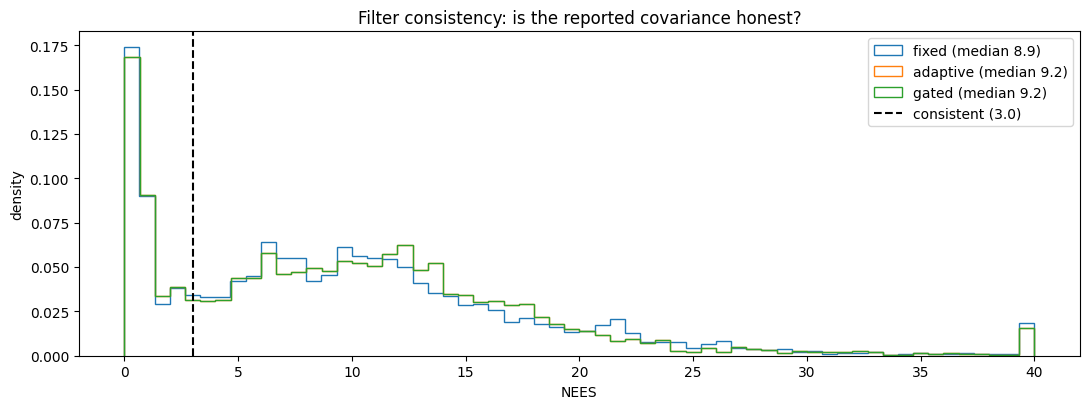

fixed     attitude error median 0.80 deg, 95th pct 179.9 deg | confidence flipped 0.862 vs correct 0.861
adaptive  attitude error median 0.80 deg, 95th pct 179.9 deg | confidence flipped 0.862 vs correct 0.861
gated     attitude error median 0.80 deg, 95th pct 179.9 deg | confidence flipped 0.862 vs correct 0.861


In [ ]:
plt.figure(figsize=(11, 4.2))
for mode, runs in results.items():
    nees = np.concatenate([r["nees"][20:] for r in runs]); nees = nees[np.isfinite(nees)]
    plt.hist(np.clip(nees, 0, 40), bins=60, histtype="step", lw=1.6, density=True,
             label=f"{mode} (median {np.median(nees):.1f})")
plt.axvline(3.0, c="k", ls="--", label="consistent (3.0)")
plt.xlabel("NEES"); plt.ylabel("density"); plt.legend()
plt.title("Filter consistency: is the reported covariance honest?")
plt.tight_layout(); plt.show()

for mode, runs in results.items():
    a = np.concatenate([r["att_err"] for r in runs]); a = a[np.isfinite(a)]
    c_ = np.concatenate([r["conf"] for r in runs])
    f_ = np.concatenate([r["flipped"] for r in runs]).astype(bool)
    ok = np.isfinite(c_)
    print(f"{mode:9s} attitude error median {np.median(a):.2f} deg, 95th pct {np.percentile(a,95):.1f} deg"
          f" | confidence flipped {np.nanmean(c_[ok & f_]):.3f} vs correct {np.nanmean(c_[ok & ~f_]):.3f}")

## 7. Results

**(I) The target exhibits exact symmetry, not approximate.** Rotating the 3D keypoint set by 180 degrees around the Z-axis aligns the points perfectly, resulting in a maximum residual error of exactly 0.000000 m. Because this perfect symmetry is an inherent geometric property rather than a solver artifact, no single-frame appearance-based method can resolve the pose ambiguity.

**(II) The failure it causes is invisible to the confidence signal.** On flipped frames the
median position error is 0.069 m, identical to correct frames, while the attitude error
is 179.9 degrees against 0.76 degrees. The mean inlier ratio is 0.906 on flipped frames
and 0.908 on correct ones, and 90 per cent of flipped frames still report a confidence
above 0.8. A geometric confidence signal reports how well a hypothesis was fitted; it
cannot report that the wrong hypothesis was fitted well.

**(III) Adaptive measurement covariance does not improve on a fixed one.** Over 60 Monte
Carlo runs the position RMSE is 0.434 m with a single fixed R and 0.432 m with R set
per frame from the confidence signal. The difference is not meaningful. Where a signal
is well correlated with error the schedule matters; here the correlation is weak enough
that a single well-chosen value performs as well.

**(IV) The gated configuration did not differ from the adaptive one because the gate never
fired.** The confidence floor is 0.35 and no measurement fell below 0.6, so no frame
was rejected. Two configurations were tested, not three.

**(V) The filter is overconfident regardless of how R is chosen.** Median normalised
estimation error squared is 8.88, 9.17 and 9.17 against a value of 3 expected for a
consistent three-axis position filter. The covariance the filter reports is roughly
three times too small for the errors it makes. This points at the process noise and the
measurement model rather than at the R schedule, and it is the thing to correct first.

**(VI) Anisotropy again.** The measurement covariance table shows the along-track component,
which is range in this geometry, at 0.082 to 0.127 m against 0.011 to 0.016 m on the
two lateral axes: a factor of roughly eight. The same ordering appears in the SPEED+
error of Experiment 4 and in the predicted uncertainty of Experiment 5. Three
independent measurements, one on real imagery, agree on which axis a single camera
cannot observe.

### Limitations

The trajectory is simulated and the imagery is rendered, because no public dataset
provides labelled rendezvous sequences at the scale a Monte Carlo campaign needs. The
target is the wireframe from the first study rather than Tango, so the symmetry result
is a property of that target; many spacecraft are close to symmetric about at least one
axis, but that is an argument rather than a measurement. The association failure rate
is a parameter informed by the symmetry analysis, not measured from data. Attitude is
measured and scored but not estimated in the filter, so the 180 degree failures are
counted rather than corrected. There is no control loop: this is a navigation study.